In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Remove the ID column
df = pd.read_csv('./data/cirrhosis.csv').drop(columns=["ID", "N_Days"])

df

,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,D,D-penicillamine,25594,M,N,N,N,S,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,CL,Placebo,13918,F,N,Y,Y,N,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,D,NaN,24472,F,NaN,NaN,NaN,N,1.2,NaN,2.96,NaN,NaN,NaN,NaN,174.0,10.9,3.0
414,C,NaN,14245,F,NaN,NaN,NaN,N,0.9,NaN,3.83,NaN,NaN,NaN,NaN,180.0,11.2,4.0
415,C,NaN,20819,F,NaN,NaN,NaN,N,1.6,NaN,3.42,NaN,NaN,NaN,NaN,143.0,9.9,3.0
416,C,NaN,21185,F,NaN,NaN,NaN,N,0.8,NaN,3.75,NaN,NaN,NaN,NaN,269.0,10.4,3.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Status         418 non-null    str    
 1   Drug           312 non-null    str    
 2   Age            418 non-null    int64  
 3   Sex            418 non-null    str    
 4   Ascites        312 non-null    str    
 5   Hepatomegaly   312 non-null    str    
 6   Spiders        312 non-null    str    
 7   Edema          418 non-null    str    
 8   Bilirubin      418 non-null    float64
 9   Cholesterol    284 non-null    float64
 10  Albumin        418 non-null    float64
 11  Copper         310 non-null    float64
 12  Alk_Phos       312 non-null    float64
 13  SGOT           312 non-null    float64
 14  Tryglicerides  282 non-null    float64
 15  Platelets      407 non-null    float64
 16  Prothrombin    416 non-null    float64
 17  Stage          412 non-null    float64
dtypes: float64(10), int64

- 17 feature columsn (ID and N_days were dropped)
    - 7 categorical (`str`)
    - 12 numerical (10 floats, 2 ints)
- 1 Target columns - `Status`
- 418 records (pretty small dataset, we'll see how it performes)
- Quite a lot of missing values (most are highy correlated with missing drug values)
    - I think that other correlations are mostly linked to the drug value missing


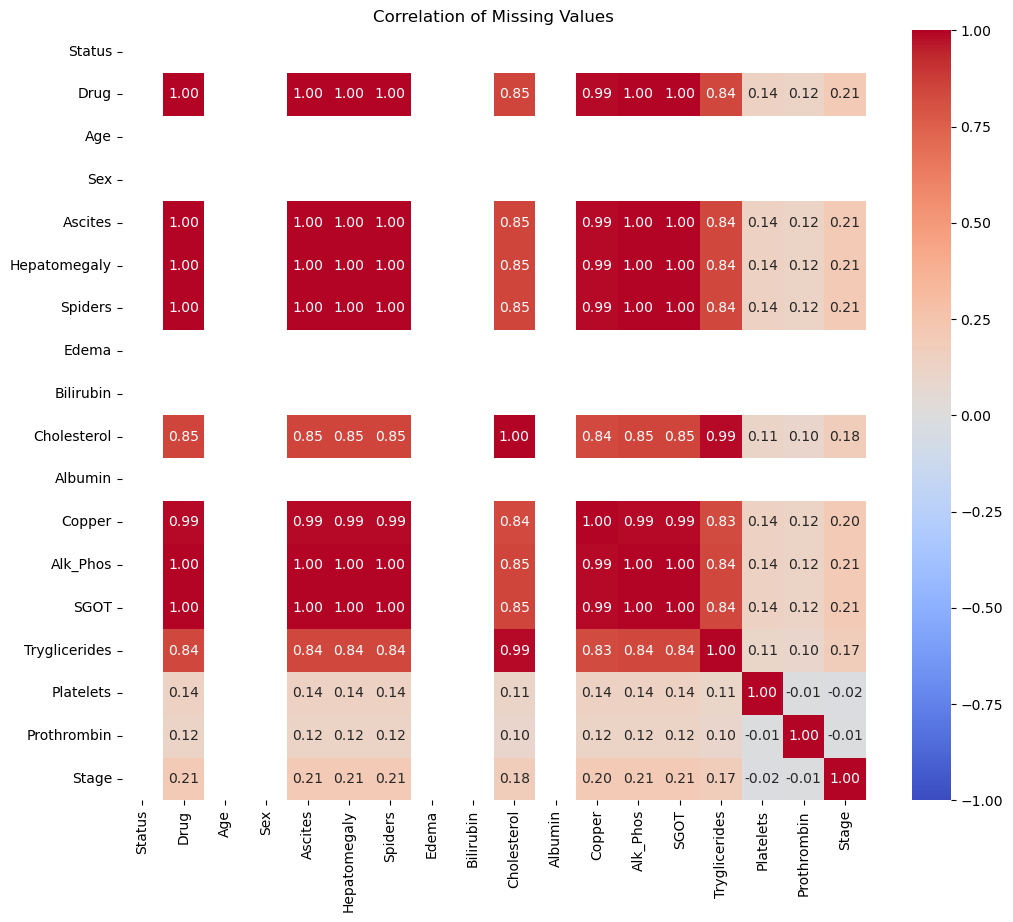

In [4]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.isna().corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Missing Values')
plt.show()


NaN in the drug column is correlatd with
- NaN in the Ascites, Hepatomegaly, Spiders categorical columns
- NaN in the Chresterol, Copper, Alk_Phos, SGOT, Tryglicerides numerical columns

It might be necessary to delete records with missing drug values. 
It is even said on the dataset website to do this.

On the other hand there are so little records in this dataset.
Might experiment with creating a new class for Drug (`Unspecified` or something like that) 

## Categorical data analysis

In [5]:
df_cat = df.select_dtypes(include=['object', 'category', 'str'])
df_cat

,Status,Drug,Sex,Ascites,Hepatomegaly,Spiders,Edema
0,D,D-penicillamine,F,Y,Y,Y,Y
1,C,D-penicillamine,F,N,Y,Y,N
2,D,D-penicillamine,M,N,N,N,S
3,D,D-penicillamine,F,N,Y,Y,S
4,CL,Placebo,F,N,Y,Y,N
...,...,...,...,...,...,...,...
413,D,NaN,F,NaN,NaN,NaN,N
414,C,NaN,F,NaN,NaN,NaN,N
415,C,NaN,F,NaN,NaN,NaN,N
416,C,NaN,F,NaN,NaN,NaN,N


In [6]:
df_cat.describe()

,Status,Drug,Sex,Ascites,Hepatomegaly,Spiders,Edema
count,418,312,418,312,312,312,418
unique,3,2,2,2,2,2,3
top,C,D-penicillamine,F,N,Y,N,N
freq,232,158,374,288,160,222,354


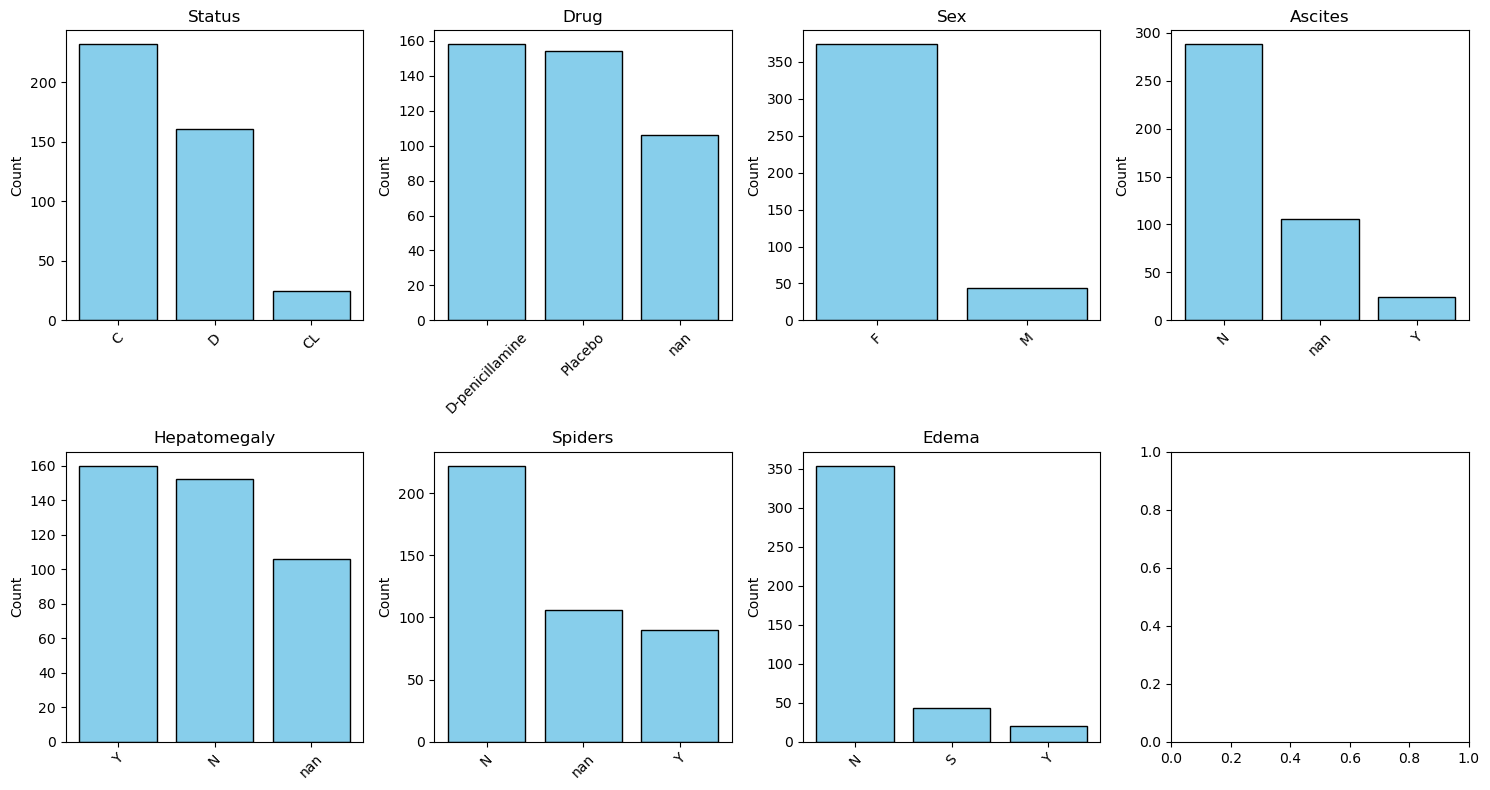

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(df_cat.columns):
    counts = df_cat[col].value_counts(dropna=False)
    
    x_labels = [str(x) for x in counts.index]
    
    axes[i].bar(x_labels, counts.values, color='skyblue', edgecolor='black')
    axes[i].set_title(f"{col}")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- Most of the distributions aren't evened out. If we were to remove the nans the only even distributions are Hepatomegaly and Durg.
- Most patients in this stydy were Female.
- High disproportion in the `Status` column (not good)

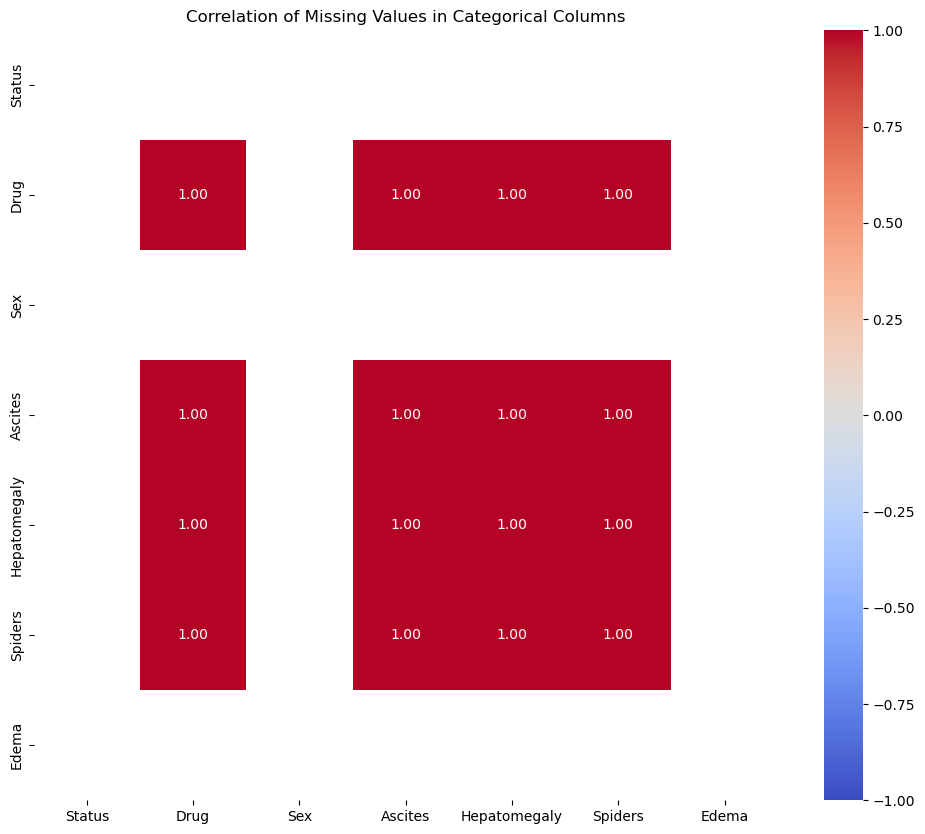

In [8]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_cat.isna().corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Missing Values in Categorical Columns')
plt.show()

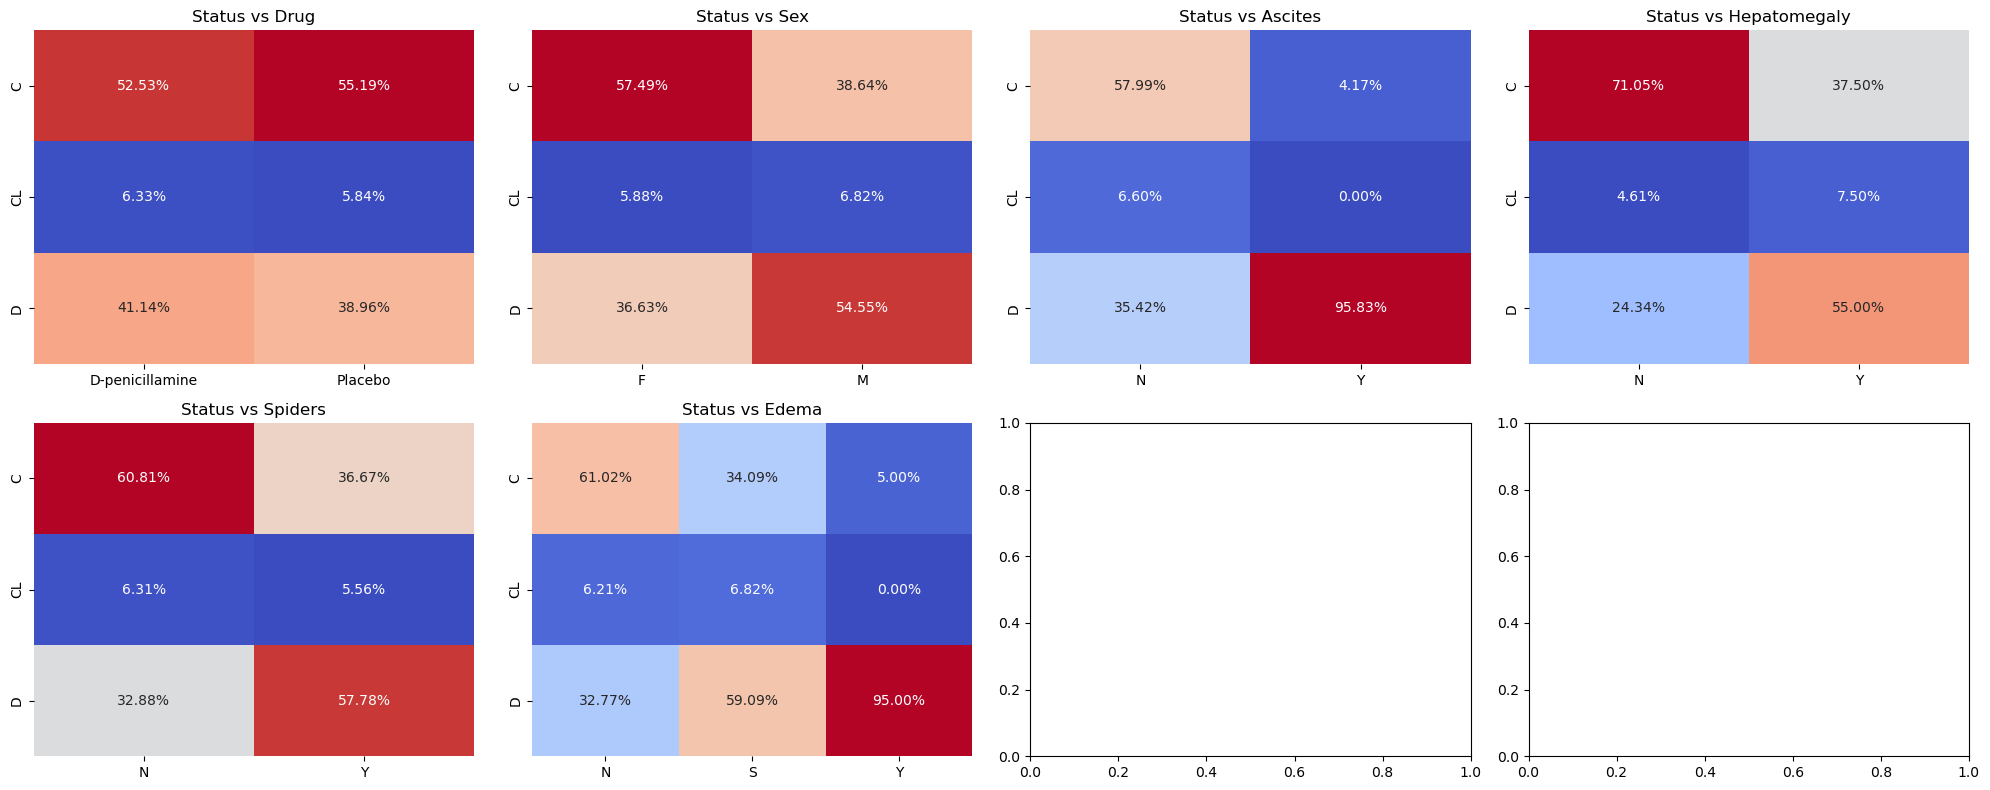

In [18]:
import math

cols = [c for c in df_cat.columns if c != 'Status']
num_plots = len(cols)

ncols = 4
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()

for idx, col in enumerate(cols):
    ct = pd.crosstab(df_cat['Status'], df_cat[col], normalize='columns')

    sns.heatmap(ct, annot=True, fmt='.2%', cmap='coolwarm', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'Status vs {col}')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('')


plt.tight_layout()
plt.show()

- Status vs Drug
    - The placebo worked similarly as the D-penicillamine
- Status vs Sex
    - Much more deadly for males
- Status vs Ascites
    - Over 95% who had Ascites died (That's a headline). 
    - This doesn't work the other way around as 35% people who didn't have Ascites also died.
    - But there is a large disproportion in data. There were like 10 times more people without Ascites.  
- Status vs Hepatomegalt
    - Pretty deadly for peaople with Hepatomegaly. For people without mostly censored.
- Status vs Spiders
    - Similar to Hematomegaly
- Status vs Edema
    - People with Edema pretty much dead as hell.
    - The S class is weird because it consists of 2 states. But people with Edema and no therapy/or no edema after the therapy have high risk of death.

## Numerical data analysis

In [10]:
df_num = df.select_dtypes(include='number')

df_num

,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,21464,14.5,261.0,2.60,156.0,1718.0,137.95,172.0,190.0,12.2,4.0
1,20617,1.1,302.0,4.14,54.0,7394.8,113.52,88.0,221.0,10.6,3.0
2,25594,1.4,176.0,3.48,210.0,516.0,96.10,55.0,151.0,12.0,4.0
3,19994,1.8,244.0,2.54,64.0,6121.8,60.63,92.0,183.0,10.3,4.0
4,13918,3.4,279.0,3.53,143.0,671.0,113.15,72.0,136.0,10.9,3.0
...,...,...,...,...,...,...,...,...,...,...,...
413,24472,1.2,NaN,2.96,NaN,NaN,NaN,NaN,174.0,10.9,3.0
414,14245,0.9,NaN,3.83,NaN,NaN,NaN,NaN,180.0,11.2,4.0
415,20819,1.6,NaN,3.42,NaN,NaN,NaN,NaN,143.0,9.9,3.0
416,21185,0.8,NaN,3.75,NaN,NaN,NaN,NaN,269.0,10.4,3.0


In [11]:
df_num.describe()

,Age,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
count,418.000000,418.000000,284.000000,418.000000,310.000000,312.000000,312.000000,282.000000,407.000000,416.000000,412.000000
mean,18533.351675,3.220813,369.510563,3.497440,97.648387,1982.655769,122.556346,124.702128,257.024570,10.731731,3.024272
std,3815.845055,4.407506,231.944545,0.424972,85.613920,2140.388824,56.699525,65.148639,98.325585,1.022000,0.882042
min,9598.000000,0.300000,120.000000,1.960000,4.000000,289.000000,26.350000,33.000000,62.000000,9.000000,1.000000
25%,15644.500000,0.800000,249.500000,3.242500,41.250000,871.500000,80.600000,84.250000,188.500000,10.000000,2.000000
50%,18628.000000,1.400000,309.500000,3.530000,73.000000,1259.000000,114.700000,108.000000,251.000000,10.600000,3.000000
75%,21272.500000,3.400000,400.000000,3.770000,123.000000,1980.000000,151.900000,151.000000,318.000000,11.100000,4.000000
max,28650.000000,28.000000,1775.000000,4.640000,588.000000,13862.400000,457.250000,598.000000,721.000000,18.000000,4.000000


- Very large standard deviations in comparisson to mean for Bilirubin, Choresterol, Copper, Alk_Phos. Suggests that the data is spreaded.
- Big differences between values between columns. Standarization/normalization needed.
- A few columns have a lot of missing values. Might need to experiment with inputation techniques.

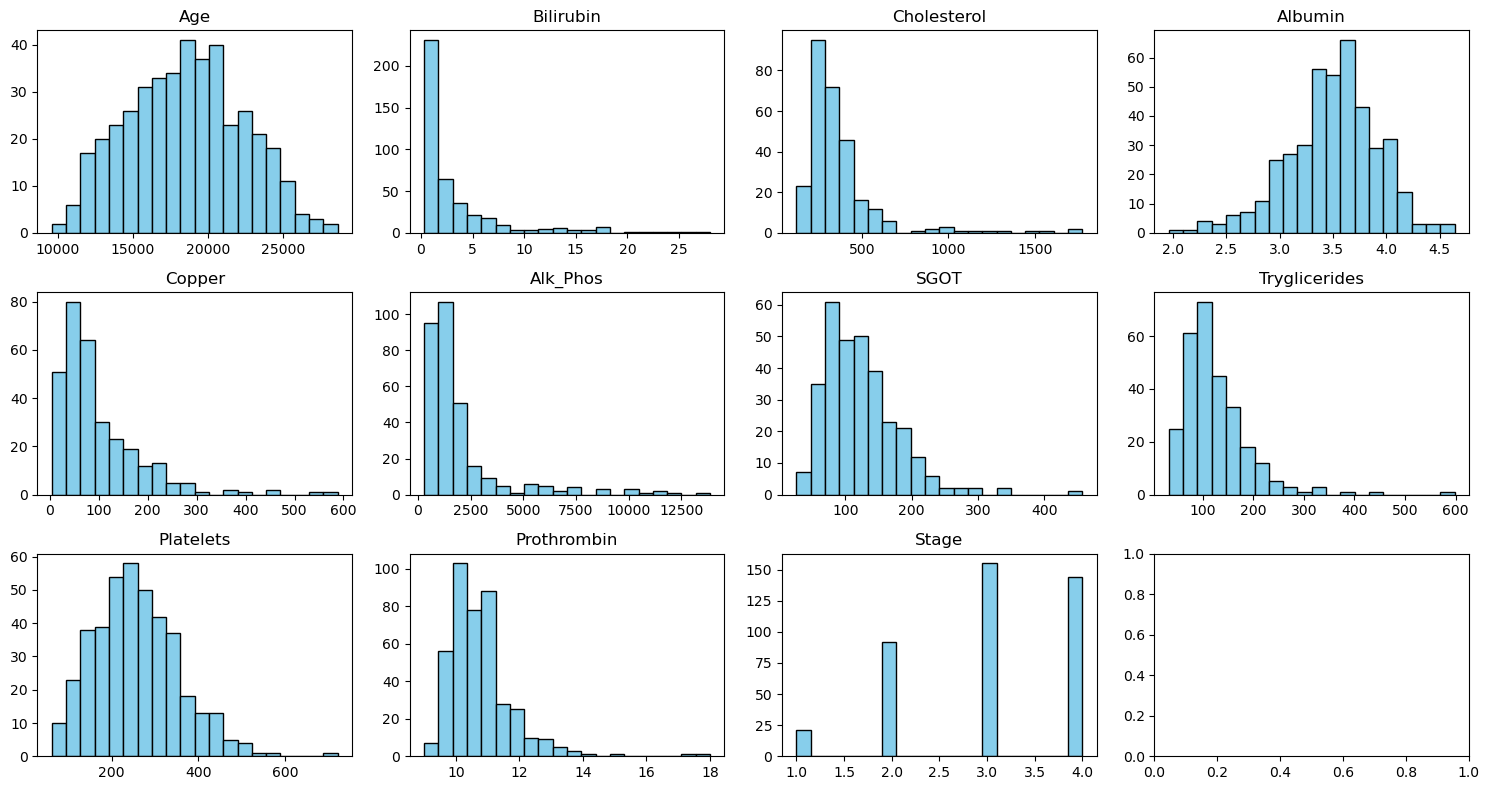

In [12]:
n_bins = 20

num_plots = len(df_num.columns)
ncols = 4
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(df_num.columns):
    axes[i].hist(df_num[col].dropna(), bins=n_bins, color='skyblue', edgecolor='black')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

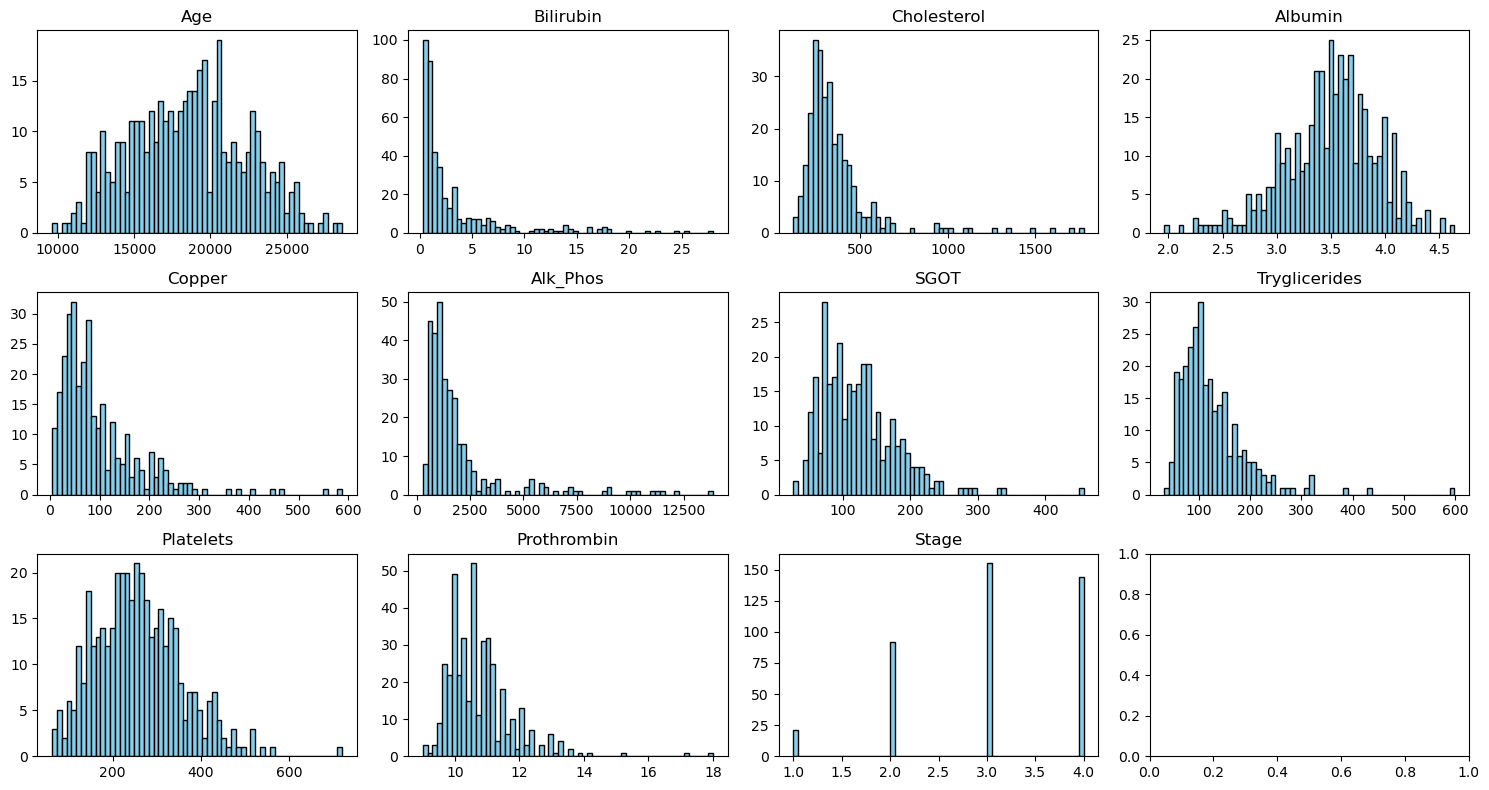

In [13]:
n_bins = 60

num_plots = len(df_num.columns)
ncols = 4
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(df_num.columns):
    axes[i].hist(df_num[col].dropna(), bins=n_bins, color='skyblue', edgecolor='black')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

- Decent distributions. Most of the columns look at least close to normal distribution.
- To there is like only 1 non normal-esque distribution. Bilirubin looks like exponential distribution.
- N_Days looks weird. Multiple smaller peaks.

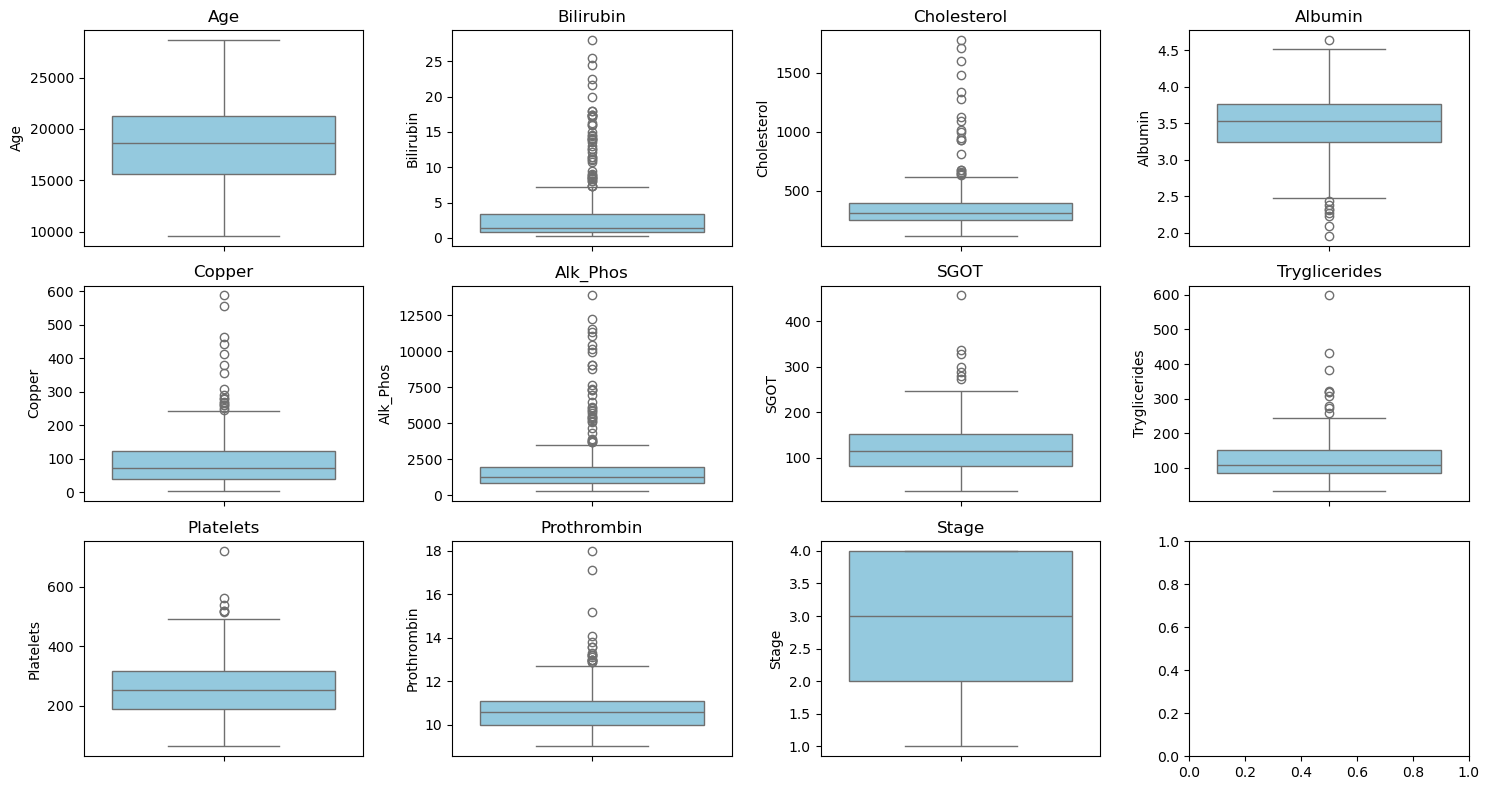

In [14]:
n_bins = 20

num_plots = len(df_num.columns)
ncols = 4
nrows = math.ceil(num_plots / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(df_num.columns):
    sns.boxplot(df_num[col], color='skyblue', ax=axes[i])
    axes[i].set_title(col)


plt.tight_layout()
plt.show()

- A lot of outliers for `Bilirubin`, `Choresterol`, `Copper`, `Alk_Phos`, `Prothrombin`.

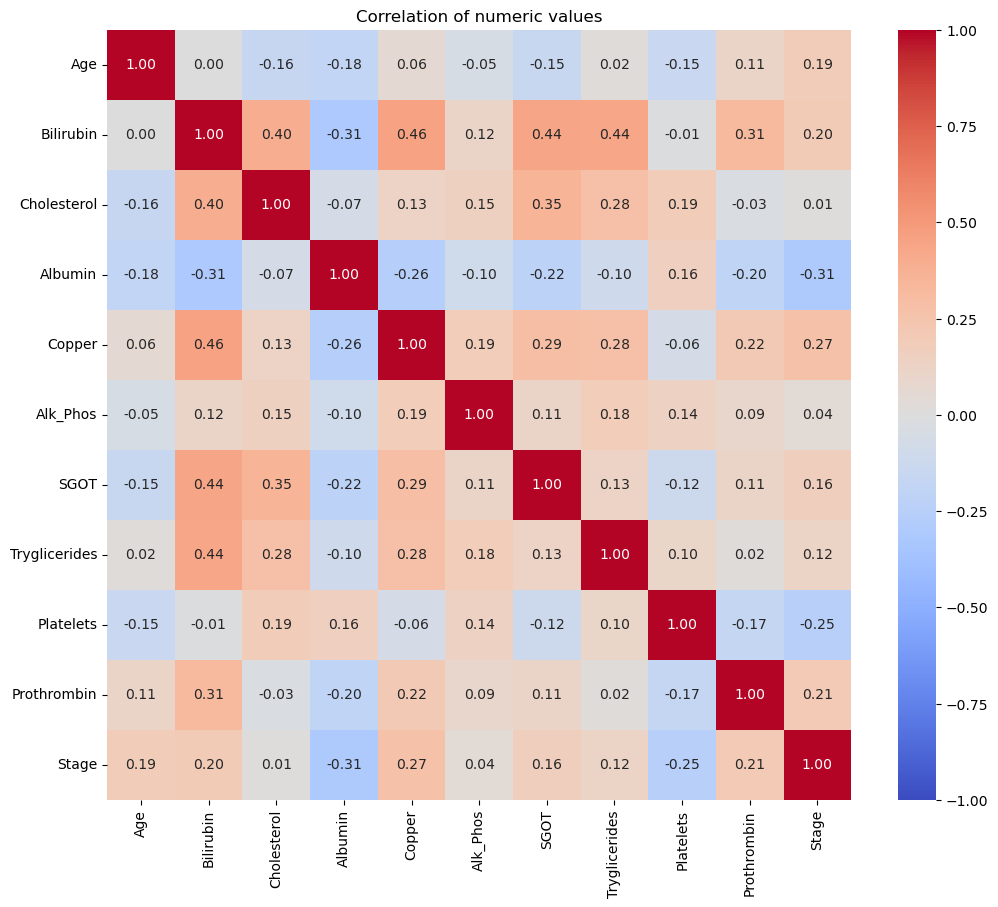

In [15]:
plt.figure(figsize=(12, 10))

correlation_matrix = df_num.corr() 

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of numeric values')
plt.show()

- The numerical colums aren't correlated too much with each other. The highest absolute corr value is 0.46 (Copper x Bilirubin).
- Each column carry some new information.  

## Correlation between numeric columns and Status

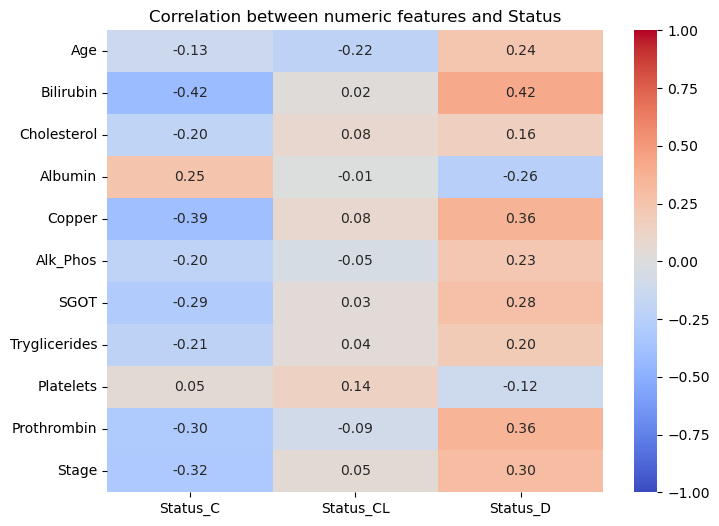

In [16]:
status_dummies = pd.get_dummies(df['Status'], prefix='Status')
corr_num_status = df_num.join(status_dummies).corr().loc[df_num.columns, status_dummies.columns]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_num_status, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between numeric features and Status')
plt.show()

- Most of the numeric columns have high positive correlation with the `D` Status. The exceptions are 
    - `N_Days`
    - Albumin
    - Piateles
- The oposite is true for the `C` Status.
- `CL` Status has the lowest correlation with anything. 
    - THe biggest absolute correlation value is with age (-0.22).
    - Might be because of the fact that this group is the smallest.